# Multivariate Random Variables

Notebook 01 introduced univariate population distributions and finite-sample moments. This notebook considers variables jointly: first their marginal and conditional distributions, then covariance and correlation, linear transformations, followed by examples of distributional families.

The general framework is multivariate, but the illustrations mainly use two variables. A bivariate density can be shown as a surface or as contours, which makes changes in shape and dependence easier to see. Notebook 03 then develops statistical inference for unknown model parameters.

For samples, $\mathbf X_1,\ldots,\mathbf X_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$ means independence across observations, not between components. This is a simplifying sampling framework. Temporal dependence in financial returns is addressed later in the time-series notebooks.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from finstats.multivariate import covariance, correlation, covariance_matrix, linear_combination_mean, linear_combination_variance
from finstats.multivariate import bivariate_symmetric_laplace_pdf

## 1. Random Vectors

A random vector collects variables observed together. Its components are random before observation; a realized vector contains their observed numerical values.

### Bivariate random variables

For two components, $\mathbf X=(X_1,X_2)^\top$ and $\mathbf x=(x_1,x_2)^\top$. The joint CDF is
$$F_{X_1,X_2}(x_1,x_2)=P(X_1\le x_1,X_2\le x_2).$$
When a density exists,
$$f_{X_1,X_2}(x_1,x_2)=\frac{\partial^2F_{X_1,X_2}(x_1,x_2)}{\partial x_1\partial x_2},$$
where the derivative exists. It is nonnegative and integrates to one. Integrating over a region gives its probability.

### Multivariate random variables

For $K$ components, $\mathbf X=(X_1,\ldots,X_K)^\top$ and $\mathbf x\in\mathbb R^K$. The same definitions become
$$F_{\mathbf X}(\mathbf x)=P(X_1\le x_1,\ldots,X_K\le x_K),\qquad
f_{\mathbf X}(\mathbf x)=\frac{\partial^K F_{\mathbf X}(\mathbf x)}{\partial x_1\cdots\partial x_K},$$
where a differentiable density representation exists. The density integrates to one over $\mathbb R^K$. Marginal distributions alone do not specify the dependence between components. Throughout, the bivariate case provides the visual illustration of these general ideas.

## 2. Marginal Distributions

### Bivariate case

Integrating out the other component gives
$$f_{X_1}(x_1)=\int_{\mathbb R}f_{X_1,X_2}(x_1,x_2)\,dx_2,\qquad
f_{X_2}(x_2)=\int_{\mathbb R}f_{X_1,X_2}(x_1,x_2)\,dx_1.$$
Marginalization averages over all possible values of the other component. It does not fix that component at zero.

### Multivariate case

Partition the vector into subvectors $\mathbf U$ and $\mathbf V$. Then
$$f_{\mathbf U}(\mathbf u)=\int f_{\mathbf U,\mathbf V}(\mathbf u,\mathbf v)\,d\mathbf v.$$
The integral removes every coordinate in $\mathbf V$. A marginal can describe one component or a subvector.

### Example: bivariate Gaussian

For $\mathbf X\sim N_2(\mu,\Sigma)$, component $X_j$ has marginal distribution $N(\mu_j,\Sigma_{jj})$. For illustration, I use $\mu=0$ and $\Sigma=I_2$, so both marginals are $N(0,1)$ and correlation is zero. The first panel shows the joint density, followed by its two marginal densities. A numerical integral at $x_1=.5$ checks the first marginal.

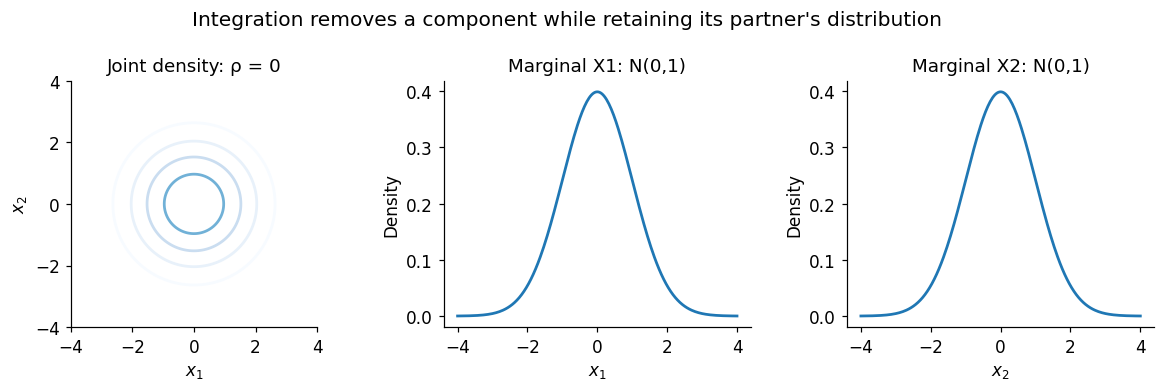

At x₁=.5: integrated joint density=0.352065, marginal Gaussian density=0.352065


In [2]:
from scipy.integrate import quad

joint_gaussian_bivariate = stats.multivariate_normal([0., 0.], np.eye(2))
marginal_grid = np.linspace(-4, 4, 241)
xx, yy = np.meshgrid(marginal_grid, marginal_grid)
points = np.stack((xx, yy), axis=-1)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
axes[0].contour(xx, yy, joint_gaussian_bivariate.pdf(points), levels=[.005, .02, .05, .1, .2], cmap="Blues")
axes[0].set(xlabel="$x_1$", ylabel="$x_2$", title="Joint density: ρ = 0", aspect="equal")
for ax, j in zip(axes[1:], (1, 2)):
    ax.plot(marginal_grid, stats.norm.pdf(marginal_grid), color="C0")
    ax.set(xlabel=f"$x_{j}$", ylabel="Density", title=f"Marginal X{j}: N(0,1)")
fig.suptitle("Integration removes a component while retaining its partner's distribution")
fig.tight_layout()
plt.show()
integrated_marginal, quadrature_error = quad(lambda x2: joint_gaussian_bivariate.pdf([.5, x2]), -np.inf, np.inf)
print(f"At x₁=.5: integrated joint density={integrated_marginal:.6f}, marginal Gaussian density={stats.norm.pdf(.5):.6f}")

## 3. Conditional Distributions

### Bivariate case

For $f_{X_1}(x_1)>0$,
$$f_{X_2\mid X_1=x_1}(x_2)=\frac{f_{X_1,X_2}(x_1,x_2)}{f_{X_1}(x_1)}.$$
Conditioning fixes the observed value of $X_1$. The denominator normalizes the resulting density. It is not the probability of an exact continuous observation, which is zero.

### Multivariate case

The corresponding subvector formula is
$$f_{\mathbf U\mid\mathbf V=\mathbf v}(\mathbf u)
=\frac{f_{\mathbf U,\mathbf V}(\mathbf u,\mathbf v)}{f_{\mathbf V}(\mathbf v)},\qquad f_{\mathbf V}(\mathbf v)>0.$$
For a Gaussian vector with partitioned mean and covariance, completing the square gives
$$\mathbf U\mid\mathbf V=\mathbf v\sim N\left(
\mu_U+\Sigma_{UV}\Sigma_{VV}^{-1}(\mathbf v-\mu_V),\;
\Sigma_{UU}-\Sigma_{UV}\Sigma_{VV}^{-1}\Sigma_{VU}\right),$$
provided $\Sigma_{VV}$ is invertible. This generalizes the bivariate Gaussian result.

### Example: conditional Gaussian distribution

To make conditioning visible, I now use unit marginal variances and $\rho=.8$, rather than the independent example above. For a general bivariate Gaussian,
$$X_2\mid X_1=x_1\sim N\left(\mu_2+\rho\sqrt{\frac{\Sigma_{22}}{\Sigma_{11}}}(x_1-\mu_1),\;\Sigma_{22}(1-\rho^2)\right).$$
I retain the course's conditioning values $x_1=-3,0,3$. Their conditional means are $-2.4,0,2.4$ and their common conditional variance is $.36$. The marginal distribution remains $N(0,1)$. In the previous zero-correlation Gaussian example, conditioning would leave this marginal unchanged.

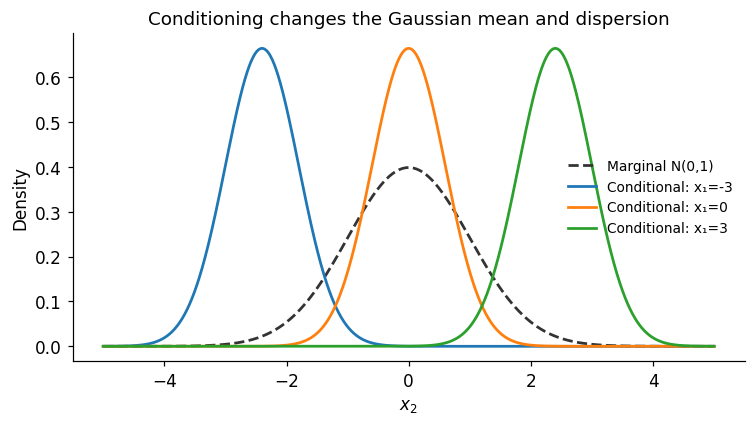

In [3]:
y_grid = np.linspace(-5, 5, 1001)
fig, ax = plt.subplots()
ax.plot(y_grid, stats.norm.pdf(y_grid), "--", color="0.2", label="Marginal N(0,1)")
for x1 in (-3, 0, 3):
    ax.plot(y_grid, stats.norm.pdf(y_grid, .8*x1, .6), label=f"Conditional: x₁={x1}")
ax.set(xlabel="$x_2$", ylabel="Density", title="Conditioning changes the Gaussian mean and dispersion")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 4. Theoretical and Empirical Covariance and Correlation

Population covariance and correlation describe the generating distribution. Their empirical counterparts are calculated from one finite sample and generally differ from the population quantities.

### Population covariance and correlation

For finite second moments,
$$\sigma_{12}=\operatorname{Cov}(X_1,X_2)=E[(X_1-\mu_1)(X_2-\mu_2)]
=E[X_1X_2]-E[X_1]E[X_2],$$
$$\rho_{12}=\frac{\sigma_{12}}{\sigma_1\sigma_2},\qquad -1\le\rho_{12}\le1,$$
provided both variances are positive. Covariance retains the product of the variables' units; correlation standardizes them. Both summarize linear dependence.

For $K$ variables, $\Sigma_{ij}=\operatorname{Cov}(X_i,X_j)$. The covariance matrix is symmetric and positive semidefinite, since $a^\top\Sigma a=E[(a^\top(\mathbf X-\mu))^2]\ge0$. If all variances are positive, its correlation matrix is $P=D^{-1}\Sigma D^{-1}$ with $D=\operatorname{diag}(\sqrt{\Sigma_{11}},\ldots,\sqrt{\Sigma_{KK}})$.

#### Gaussian density, variance and correlation

For a centered bivariate Gaussian,
$$\Sigma=\begin{pmatrix}\sigma_{11}&\rho\sqrt{\sigma_{11}\sigma_{22}}\\\rho\sqrt{\sigma_{11}\sigma_{22}}&\sigma_{22}\end{pmatrix}.$$
The diagonal entries are **variances**, not standard deviations. Changing a marginal variance stretches or compresses the density along that axis. Changing correlation tilts its contours, while leaving the specified marginal distributions unchanged.

For illustration, I follow the course comparison: unit variances with zero correlation, variance $\sigma_{11}=.2$ with zero correlation, and unit variances with $\rho=.5$. In the last case, covariance is $\sigma_{12}=.5$. A nonzero correlation cannot accompany zero covariance when both variances are positive.

The upper panels show population density surfaces. The lower panels show the same density as labeled contours, with 400 IID simulated observations per case using seed 209. All cases use the same underlying standard Gaussian draws, transformed to their specified covariance. The dots are finite realizations, not the population density itself.

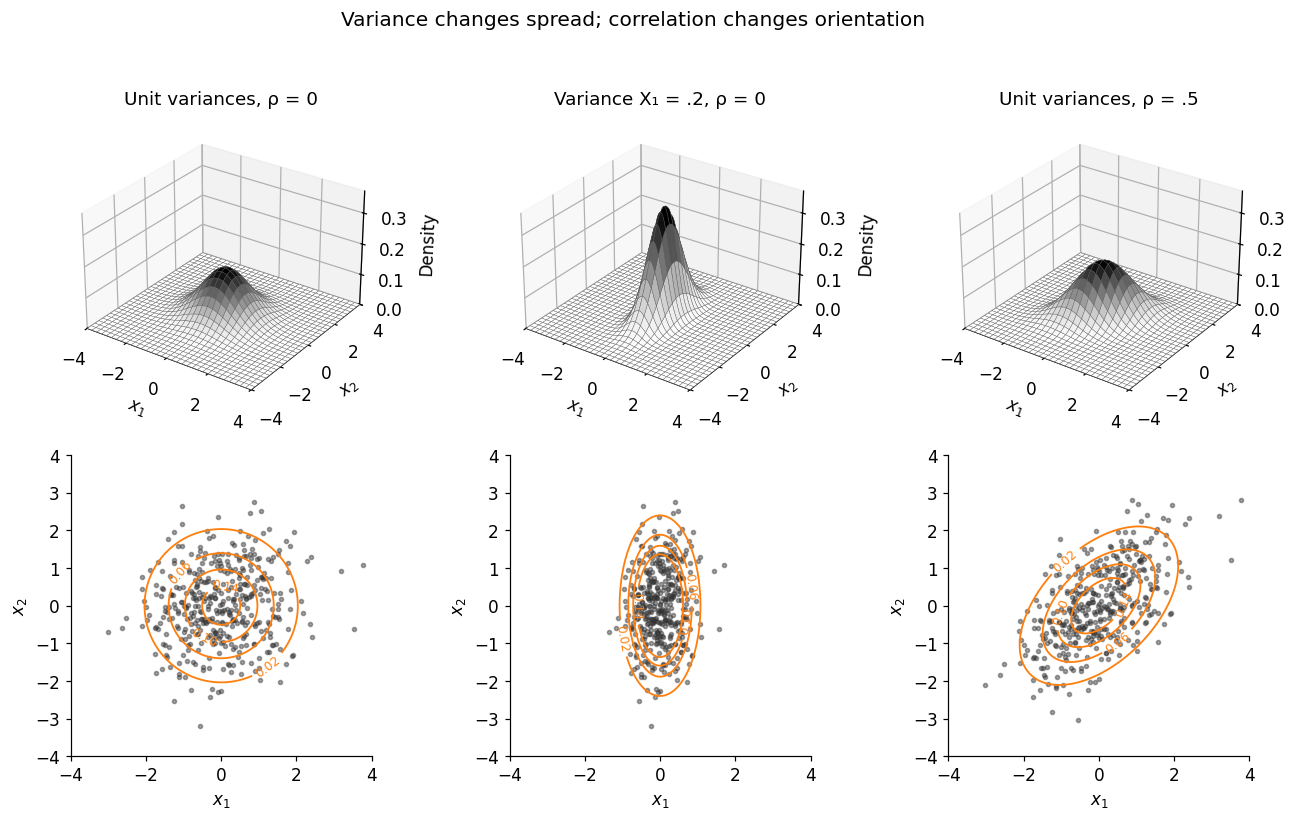

In [4]:
gaussian_grid = np.linspace(-4, 4, 161)
xx, yy = np.meshgrid(gaussian_grid, gaussian_grid)
points = np.stack((xx, yy), axis=-1)
cases = (("Unit variances, ρ = 0", np.eye(2)),
         ("Variance X₁ = .2, ρ = 0", np.diag([.2, 1.])),
         ("Unit variances, ρ = .5", np.array([[1., .5], [.5, 1.]])))
standard_draws = np.random.default_rng(209).normal(size=(400, 2))
fig = plt.figure(figsize=(12, 7.5))
for j, (title, Sigma_case) in enumerate(cases):
    distribution = stats.multivariate_normal([0., 0.], Sigma_case)
    density = distribution.pdf(points)
    surface = fig.add_subplot(2, 3, j+1, projection="3d")
    surface.plot_surface(xx, yy, density, rstride=5, cstride=5,
                         cmap="Greys", edgecolor="0.35", linewidth=.25, antialiased=True)
    surface.set(xlabel="$x_1$", ylabel="$x_2$", zlabel="Density", title=title,
                xlim=(-4, 4), ylim=(-4, 4), zlim=(0, .37))
    surface.view_init(elev=28, azim=-55)
    surface.set_box_aspect((1, 1, .65))
    ax = fig.add_subplot(2, 3, j+4)
    simulated = standard_draws @ np.linalg.cholesky(Sigma_case).T
    ax.scatter(simulated[:, 0], simulated[:, 1], s=7, color="0.2", alpha=.45)
    contours = ax.contour(xx, yy, density, levels=[.02, .06, .10, .14], colors="C1", linewidths=1.2)
    ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
    ax.set(xlabel="$x_1$", ylabel="$x_2$", xlim=(-4, 4), ylim=(-4, 4), aspect="equal")
fig.suptitle("Variance changes spread; correlation changes orientation", y=.99)
fig.tight_layout(rect=(0, 0, 1, .96), h_pad=2, w_pad=2)
plt.show()

#### Zero correlation and nonlinear dependence

Independence implies zero covariance when the moments exist. The converse holds for jointly Gaussian variables, but not generally.

For illustration, let $X\sim N(0,1)$ and $Y=X^2$. Then $E[X]=0$, $E[Y]=1$ and
$$\operatorname{Cov}(X,Y)=E[X^3]-E[X]E[X^2]=0.$$
Both variances are positive, so population correlation is zero. Nevertheless, $Y$ is determined by $X$. The joint distribution lies on a parabola, rather than having a two-dimensional density.

I draw 2000 IID pairs using seed 208. The scatter shows the dependence that correlation misses. The printed sample correlation need not be exactly zero.

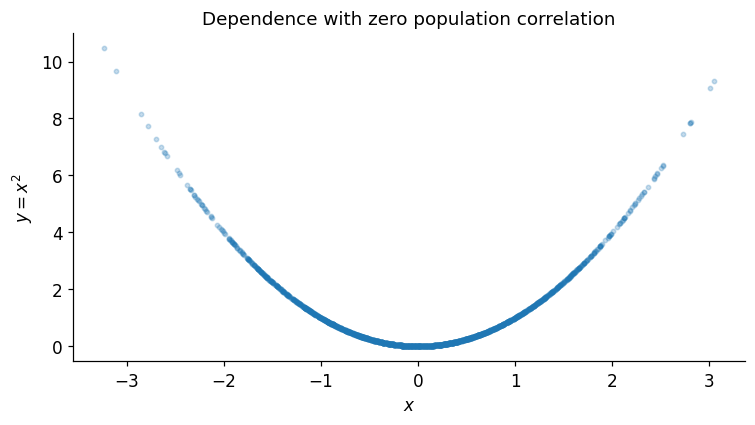

Population covariance / correlation: 0 / 0
Sample covariance / correlation: -0.0038 / -0.0029


In [5]:
x = np.random.default_rng(208).normal(size=2000)
y = x**2
fig, ax = plt.subplots()
ax.scatter(x, y, s=8, alpha=.25)
ax.set(xlabel="$x$", ylabel="$y=x^2$", title="Dependence with zero population correlation")
fig.tight_layout()
plt.show()
print(f"Population covariance / correlation: 0 / 0")
print(f"Sample covariance / correlation: {covariance(x, y):.4f} / {correlation(x, y):.4f}")

### Empirical covariance and correlation

For paired observations, center each component using its sample mean:
$$\bar x_j=\frac1n\sum_i x_{ij},\qquad d_{ij}=x_{ij}-\bar x_j.$$
Then
$$s_j^2=\frac1{n-1}\sum_i d_{ij}^2,\qquad
\hat\sigma_{12}=\frac1{n-1}\sum_i d_{i1}d_{i2},\qquad
\hat\rho_{12}=\frac{\hat\sigma_{12}}{s_1s_2}.$$
The general sample covariance matrix is
$$\widehat\Sigma=\frac1{n-1}\sum_i(\mathbf x_i-\bar{\mathbf x})(\mathbf x_i-\bar{\mathbf x})^\top.$$
Its diagonal contains sample variances and its off-diagonal entries contain sample covariances. Standardizing by sample standard deviations gives the sample correlation matrix. These are empirical descriptions, not known population relationships.

### Example: departures from population covariance

For a continuous sampling distribution, exact equality to population covariance is generally not a useful criterion. The question is how large the estimation error can be.

For illustration, I retain 1000 IID Gaussian samples at each $n=20,100,1000$, with mean zero, unit variances, correlation $.6$ and seed 211. The first size-20 sample illustrates the centered-product calculation. The repeated-sample table reports covariance dispersion and the percentage of estimates more than $.1$ away from the true covariance $.6$. This tolerance is an illustrative accuracy threshold, not a hypothesis test. The existing histogram shows the full spread of covariance estimates.

In [6]:
rng_repeated = np.random.default_rng(211)
replications = 1000
sample_sizes = (20, 100, 1000)
true_sigma = np.array([[1., 0.6], [0.6, 1.]])
repeated_matrices = {}
repeated_correlations = {}
repeated_means = {}
for n in sample_sizes:
    standard_samples = rng_repeated.normal(size=(replications, n, 2))
    samples = np.stack((standard_samples[:, :, 0],
                        0.6*standard_samples[:, :, 0]+0.8*standard_samples[:, :, 1]), axis=-1)
    if n == 20:
        first_sample = samples[0].copy()
    repeated_means[n] = np.mean(samples, axis=1)
    repeated_matrices[n] = np.array([covariance_matrix(row) for row in samples])
    repeated_correlations[n] = np.array([correlation(row[:, 0], row[:, 1]) for row in samples])

# The first size-20 realization makes the sample formulas explicit.
n_observed = len(first_sample)
observed_mean = np.array([sample_mean(first_sample[:, j]) for j in range(2)])
centered = first_sample-observed_mean
sums = [np.sum(centered[:, 0]**2), np.sum(centered[:, 1]**2),
        np.sum(centered[:, 0]*centered[:, 1])]
observed_covariance = covariance_matrix(first_sample)
observed_correlation = correlation(first_sample[:, 0], first_sample[:, 1])
calculation_rows = [
    ["Variance X₁", sums[0], n_observed-1, observed_covariance[0, 0], 1.],
    ["Variance X₂", sums[1], n_observed-1, observed_covariance[1, 1], 1.],
    ["Covariance", sums[2], n_observed-1, observed_covariance[0, 1], .6],
    ["Correlation", observed_covariance[0, 1], np.sqrt(observed_covariance[0, 0]*observed_covariance[1, 1]), observed_correlation, .6],
]
print(f"First realization: n={n_observed}, sample means={observed_mean.round(4)}")
display(pd.DataFrame(calculation_rows, columns=["Quantity", "Numerator", "Denominator", "Sample value", "Population value"]).round(4))
print(f"Sample correlation {observed_correlation:.4f} differs from population correlation 0.6000.")

summary_rows = []
for n in sample_sizes:
    covariances = repeated_matrices[n][:, 0, 1]
    lower, upper = np.quantile(covariances, [.1, .9])
    summary_rows.append([n, .6, sample_mean(covariances), sample_standard_deviation(covariances),
                         lower, upper, 100*np.mean(np.abs(covariances-.6) > .1),
                         sample_mean(repeated_correlations[n])])
display(pd.DataFrame(summary_rows, columns=["n", "Population covariance", "Mean sample covariance", "Replication SD",
                                            "10th percentile", "90th percentile", "% error > .1", "Mean sample correlation"]).round(4))

First realization: n=20, sample means=[-0.0188  0.0036]


,Quantity,Numerator,Denominator,Sample value,Population value
0,Variance X₁,17.4116,19.0000,0.9164,1.0
1,Variance X₂,17.6077,19.0000,0.9267,1.0
2,Covariance,13.7079,19.0000,0.7215,0.6
3,Correlation,0.7215,0.9215,0.7829,0.6


Sample correlation 0.7829 differs from population correlation 0.6000.


,n,Population covariance,Mean sample covariance,Replication SD,10th percentile,90th percentile,% error > .1,Mean sample correlation
0,20,0.6,0.6059,0.2584,0.2860,0.9615,67.3,0.5946
1,100,0.6,0.5973,0.1154,0.4514,0.7444,38.6,0.5973
2,1000,0.6,0.5994,0.0372,0.5516,0.6456,0.4,0.5993


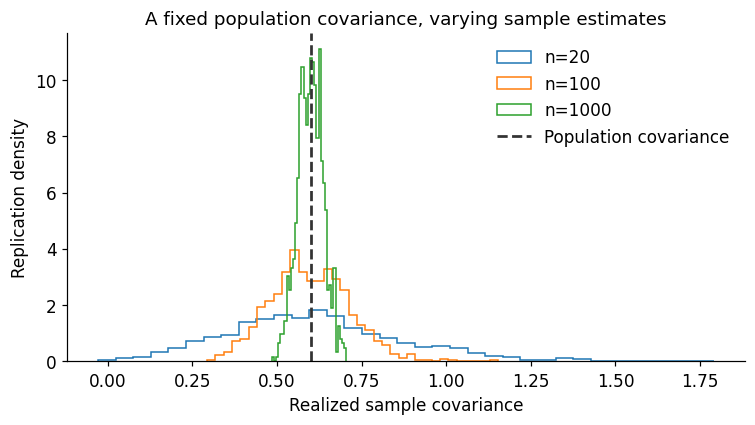

In [7]:
fig, ax = plt.subplots()
for n in sample_sizes:
    ax.hist(repeated_matrices[n][:, 0, 1], bins=35, density=True, histtype="step", label=f"n={n}")
ax.axvline(.6, color="0.2", linestyle="--", label="Population covariance")
ax.set(xlabel="Realized sample covariance", ylabel="Replication density", title="A fixed population covariance, varying sample estimates")
ax.legend()
fig.tight_layout()
plt.show()

The target covariance is fixed, but the estimates vary across samples. Smaller samples can give substantial departures, while larger samples reduce their spread. A realized covariance or correlation remains an estimate, even when the parametric model is exactly the DGP.

## 5. Linear Combinations and Transformations

Covariance and correlation describe the original variables. A linear combination or transformation constructs new variables from them. The dependence described in Section 4 determines the dispersion of those new variables.

Write $\mu=E[\mathbf X]$ and $\Sigma=E[(\mathbf X-\mu)(\mathbf X-\mu)^\top]$ when second moments are finite. An affine transformation uses a fixed $m\times K$ matrix $A$ and vector $b$:
$$\mathbf Y=A\mathbf X+b.$$

### Mean of a linear transformation

Linearity of expectation gives
$$E[\mathbf Y]=A\mu+b.$$
A scalar linear combination $Y=c_0+c^\top\mathbf X$ therefore has $E[Y]=c_0+c^\top\mu$. The intercept shifts the mean.

### Variance and covariance of linear transformations

Centering gives $\mathbf Y-E[\mathbf Y]=A(\mathbf X-\mu)$. Taking the expectation of its outer product yields
$$\operatorname{Cov}(\mathbf Y)=A\Sigma A^\top.$$
For a scalar combination,
$$\operatorname{Var}(c_0+c^\top\mathbf X)=c^\top\Sigma c
=\sum_j c_j^2\Sigma_{jj}+2\sum_{j<k}c_jc_k\Sigma_{jk}.$$
In the bivariate case, this is $c_1^2\sigma_1^2+c_2^2\sigma_2^2+2c_1c_2\sigma_{12}$. The intercept disappears from variance. These identities do not require Gaussianity or independence.



The following illustration applies these identities to Gaussian, Student-t and Laplace distributions. Section 6 gives their general multivariate definitions.


### Illustrating linear transformations across families

An invertible affine transformation preserves each of the three families used below. Gaussian covariance transforms as $A\Sigma A^\top$. Student-t **scale** transforms as $ASA^\top$, with degrees of freedom unchanged. The symmetric Laplace construction is $\mathbf X=\sqrt W\,\mathbf Z$, where $W\sim Exp(1)$ is independent of $\mathbf Z\sim N(0,\Sigma)$; applying $A$ to $\mathbf Z$ preserves that construction, with the location shifted by $b$.

For illustration, all three input distributions have mean zero and covariance $I_2$. I apply
$$A=\begin{pmatrix}1.5&.8\\0&.7\end{pmatrix},\qquad b=\begin{pmatrix}2\\-1\end{pmatrix}.$$
Every transformed distribution has mean $(2,-1)^\top$ and covariance $\left(\begin{smallmatrix}2.89&.56\\.56&.49\end{smallmatrix}\right)$, while the family shapes differ. The upper surfaces show the original densities and the lower surfaces their transformed densities. For nonsingular $A$,
$$f_{\mathbf Y}(\mathbf y)=\frac{f_{\mathbf X}(A^{-1}(\mathbf y-b))}{|\det A|}.$$
The Student-t uses $\nu=5$ and input scale $3I_2/5$. Within each column, density axes have the same scale. The Laplace density is unbounded at its center, so the even grid avoids the center and its displayed peak depends on resolution.

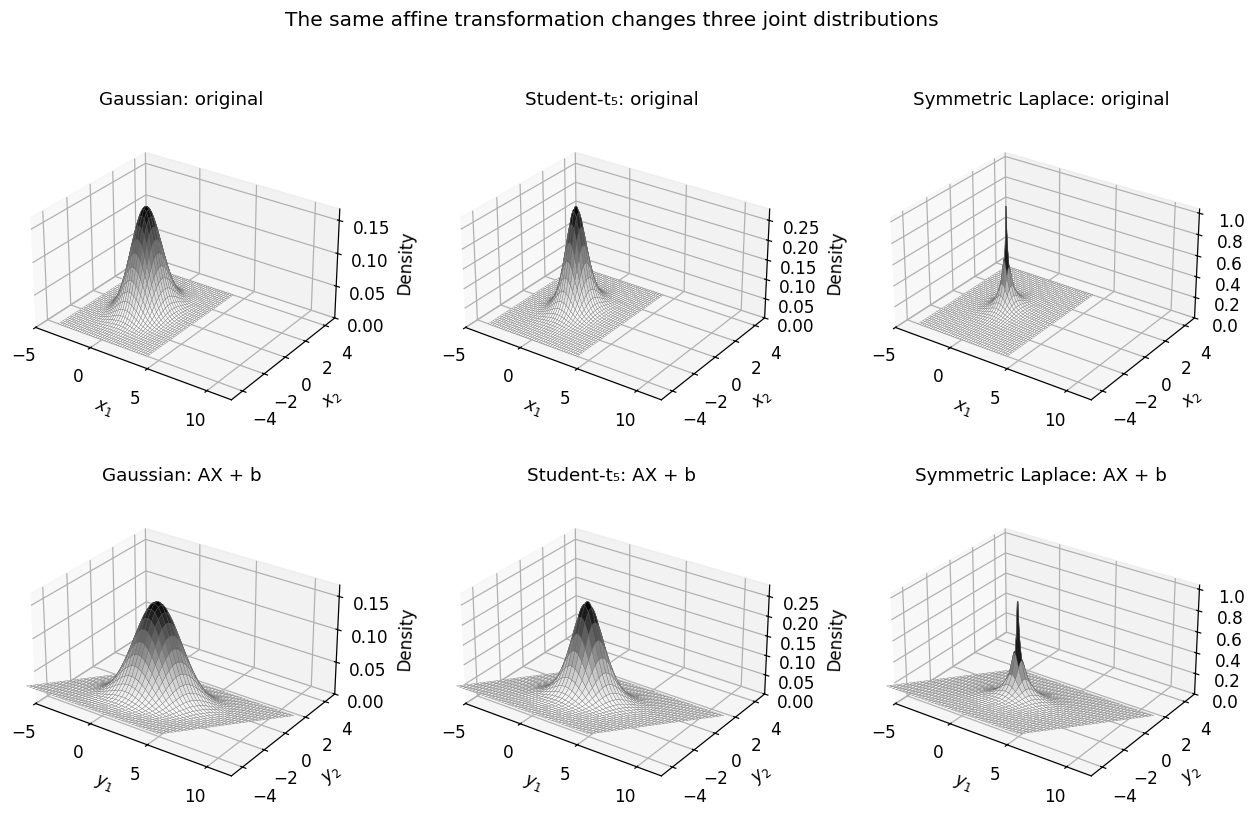

Transformed population mean: [ 2. -1.]
Transformed population covariance:
 [[2.89 0.56]
 [0.56 0.49]]


In [8]:
gaussian_input = stats.multivariate_normal([0., 0.], np.eye(2))
t_input = stats.multivariate_t([0., 0.], shape=3*np.eye(2)/5, df=5)
family_densities = {
    "Gaussian": gaussian_input.pdf,
    "Student-t₅": t_input.pdf,
    "Symmetric Laplace": lambda points: bivariate_symmetric_laplace_pdf(points, [0., 0.], np.eye(2)),
}
A = np.array([[1.5, .8], [0., .7]])
b = np.array([2., -1.])
original_grid = np.linspace(-4, 4, 160)
ox, oy = np.meshgrid(original_grid, original_grid)
original_points = np.stack((ox, oy), axis=-1)
# Map the same grid through A, retaining the same points on each surface.
transformed_points = original_points @ A.T+b
jacobian = abs(np.linalg.det(A))
fig = plt.figure(figsize=(12, 7.5))
for j, (name, pdf) in enumerate(family_densities.items()):
    original_density = pdf(original_points)
    transformed_density = original_density/jacobian
    z_limit = 1.05*max(original_density.max(), transformed_density.max())
    for row, points, density, title in (
            (0, original_points, original_density, f"{name}: original"),
            (1, transformed_points, transformed_density, f"{name}: AX + b")):
        ax = fig.add_subplot(2, 3, row*3+j+1, projection="3d")
        ax.plot_surface(points[..., 0], points[..., 1], density, rstride=4, cstride=4,
                        cmap="Greys", edgecolor="0.4", linewidth=.2)
        ax.set(xlabel="$x_1$" if row == 0 else "$y_1$", ylabel="$x_2$" if row == 0 else "$y_2$",
               zlabel="Density", title=title, zlim=(0, z_limit), xlim=(-5, 12), ylim=(-5, 5))
        ax.view_init(elev=28, azim=-55)
        ax.set_box_aspect((1.25, 1, .65))
fig.suptitle("The same affine transformation changes three joint distributions", y=.99)
fig.tight_layout(rect=(0, 0, 1, .96), h_pad=2)
plt.show()
print("Transformed population mean:", b)
print("Transformed population covariance:\n", A @ A.T)

## 6. Examples of Multivariate Distributions

The following families illustrate symmetry, tail behavior and skewness. Their parameters are population quantities, which remain unknown in applications. The surfaces use two variables to visualize the general multivariate definitions.

### Gaussian distribution

For $\mu\in\mathbb R^K$ and positive-definite $\Sigma$, the density is
$$f(\mathbf x)=\frac{\exp[-\tfrac12(\mathbf x-\mu)^\top\Sigma^{-1}(\mathbf x-\mu)]}{(2\pi)^{K/2}\sqrt{\det\Sigma}}.$$
Mean and covariance determine the Gaussian distribution. Zero covariance between its components implies independence. The illustration uses $N_2(0,I_2)$.

### Student-t distribution

For $\mu\in\mathbb R^K$, positive-definite scale matrix $S$ and $\nu>0$,
$$f(\mathbf x)=\frac{\Gamma((\nu+K)/2)}{\Gamma(\nu/2)(\nu\pi)^{K/2}\sqrt{\det S}}
\left[1+\frac{(\mathbf x-\mu)^\top S^{-1}(\mathbf x-\mu)}{\nu}\right]^{-(\nu+K)/2}.$$
Mean is $\mu$ for $\nu>1$, and covariance is $\nu S/(\nu-2)$ for $\nu>2$. The scale is not the covariance. The illustration uses $\nu=5$, $\mu=0$ and $S=3I_2/5$, giving covariance $I_2$. These components are uncorrelated but not independent: a common random scale contributes to their joint tail behavior.

### Laplace distribution

I use the symmetric normal–exponential construction:
$$\mathbf X=\mu+\sqrt W\,\mathbf Z,\qquad W\sim Exp(1),\qquad \mathbf Z\sim N_K(0,\Sigma),$$
with independent $W$ and $\mathbf Z$. Its mean is $\mu$ and covariance is $\Sigma$, since $E[W]=1$. Each component is $Laplace(\mu_j,\sqrt{\Sigma_{jj}/2})$. The shared mixture variable matters: this is not a product of independent Laplace densities, and arbitrary sums of independent Laplace variables need not be Laplace.

For $K=2$, away from its center,
$$f(\mathbf x)=\frac{K_0\left(\sqrt{2(\mathbf x-\mu)^\top\Sigma^{-1}(\mathbf x-\mu)}\right)}{\pi\sqrt{\det\Sigma}},$$
where $K_0$ is the modified Bessel function. This density follows by integrating the conditional Gaussian density over $W$. It is unbounded at the center, but integrates to one. The illustration uses $\mu=0$ and $\Sigma=I_2$: its components have zero correlation while remaining dependent.

### Standard skew-normal distribution

A standard multivariate extension of Notebook 01's skew-normal density is
$$f(\mathbf x)=2\phi_K(\mathbf x;\Omega)\Phi(\alpha^\top\mathbf x),\qquad \alpha\in\mathbb R^K,$$
where $\phi_K$ is a centered Gaussian density with positive-definite correlation matrix $\Omega$, and $\Phi$ is the univariate Gaussian CDF. With $\delta=\Omega\alpha/\sqrt{1+\alpha^\top\Omega\alpha}$,
$$E[\mathbf X]=\sqrt{2/\pi}\,\delta,\qquad
\operatorname{Cov}(\mathbf X)=\Omega-\frac2\pi\delta\delta^\top.$$
Thus $\Omega$ is not generally the covariance of the skew-normal vector.

For the uncorrelated illustration, I use $\Omega=I_2$ and $\alpha=(3,0)^\top$. This gives $SN(0,1,3)$ for $X_1$ and an independent standard Gaussian $X_2$. Standard location and scale do not imply a zero mean or unit variance for the skewed component. Skewness in one direction changes the surface without adding correlation.

### Illustrating the bivariate distributions

For illustration, I use two components to display the four multivariate densities. The Gaussian, Student-t and symmetric Laplace examples have mean zero and covariance $I_2$. The skew-normal uses its standard parameterization with $\Omega=I_2$ and $\alpha=(3,0)^\top$, so its mean and covariance differ. All four have zero population correlation. This implies independence for the Gaussian example, but not for the Student-t or symmetric Laplace examples.

These are population density surfaces, rather than samples. The horizontal ranges are the same, while density axes vary across families. The Laplace density is infinite at its center. An even grid avoids that point, and the displayed peak depends on grid resolution.


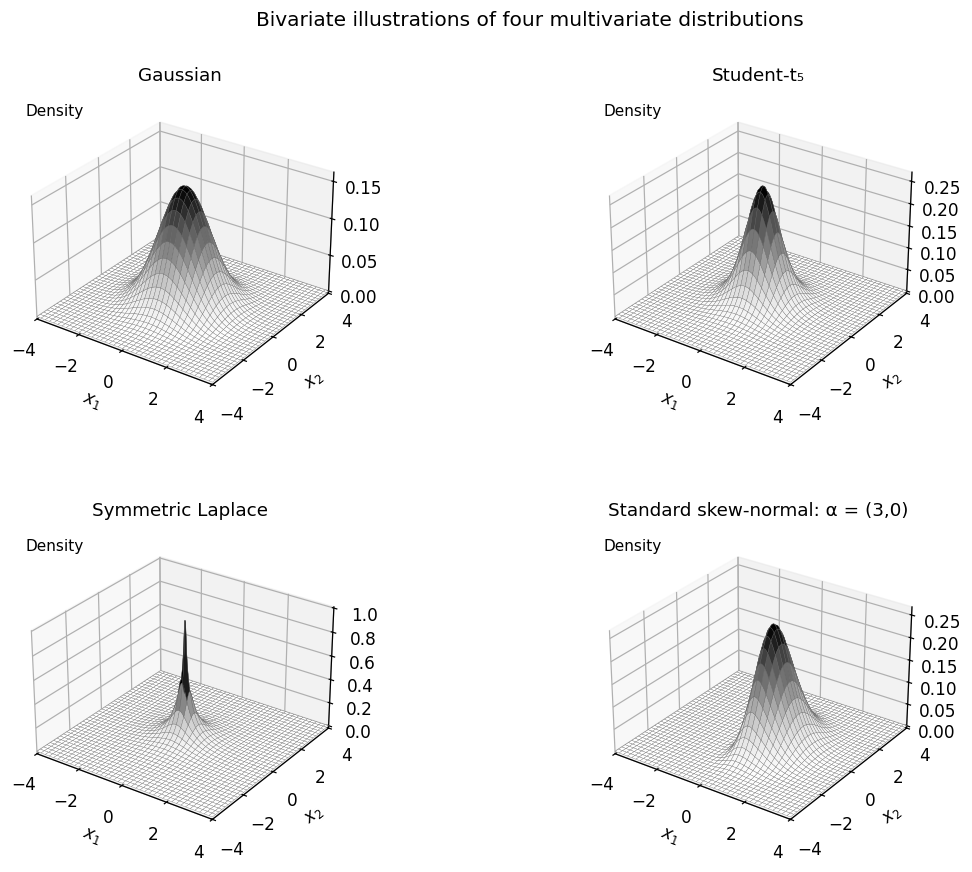

In [9]:
surface_grid = np.linspace(-4, 4, 160)
xx, yy = np.meshgrid(surface_grid, surface_grid)
points = np.stack((xx, yy), axis=-1)
four_densities = {name: pdf(points) for name, pdf in family_densities.items()}
four_densities["Standard skew-normal: α = (3,0)"] = (
    2*stats.multivariate_normal([0., 0.], np.eye(2)).pdf(points)*stats.norm.cdf(3*xx))
fig = plt.figure(figsize=(11, 8))
for j, (name, density) in enumerate(four_densities.items(), 1):
    ax = fig.add_subplot(2, 2, j, projection="3d")
    ax.plot_surface(xx, yy, density, rstride=4, cstride=4, cmap="Greys",
                    edgecolor="0.4", linewidth=.2)
    ax.set(xlabel="$x_1$", ylabel="$x_2$", title=name,
           xlim=(-4, 4), ylim=(-4, 4))
    ax.text2D(.02, .92, "Density", transform=ax.transAxes, fontsize=10)
    ax.view_init(elev=28, azim=-55)
    ax.set_box_aspect((1, 1, .65))
fig.suptitle("Bivariate illustrations of four multivariate distributions", y=.99)
fig.subplots_adjust(left=.02, right=.88, bottom=.04, top=.9, wspace=.25, hspace=.35)
plt.show()


Joint distributions describe more than marginal shapes or linear dependence alone. Transformations preserve the moment identities, while finite samples supply imperfect estimates of their population inputs. Notebook 03 develops statistical inference for these unknown parameters.